In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import pandas as pd

In [14]:
fs = 1000
N = 1000

att_min = 40

fs1 = 10
fc1 = 100
fc2 = 150
fs2 = 240

ripple_db = 1

fc = [fc1, fc2]
fst = [fs1, fs2]

sos = sig.iirdesign(wp=fc, ws=fst, gpass=ripple_db, gstop=att_min, 
                    ftype='butter', analog=False, 
                    fs=fs, output='sos')

In [15]:
pd.DataFrame(sos).head()

,0,1,2,3,4,5
0,0.000759,0.001519,0.000759,1.0,-1.114141,0.687309
1,1.000000,2.000000,1.000000,1.0,-1.317567,0.725184
2,1.000000,-2.000000,1.000000,1.0,-1.059886,0.848910
3,1.000000,-2.000000,1.000000,1.0,-1.544006,0.891100


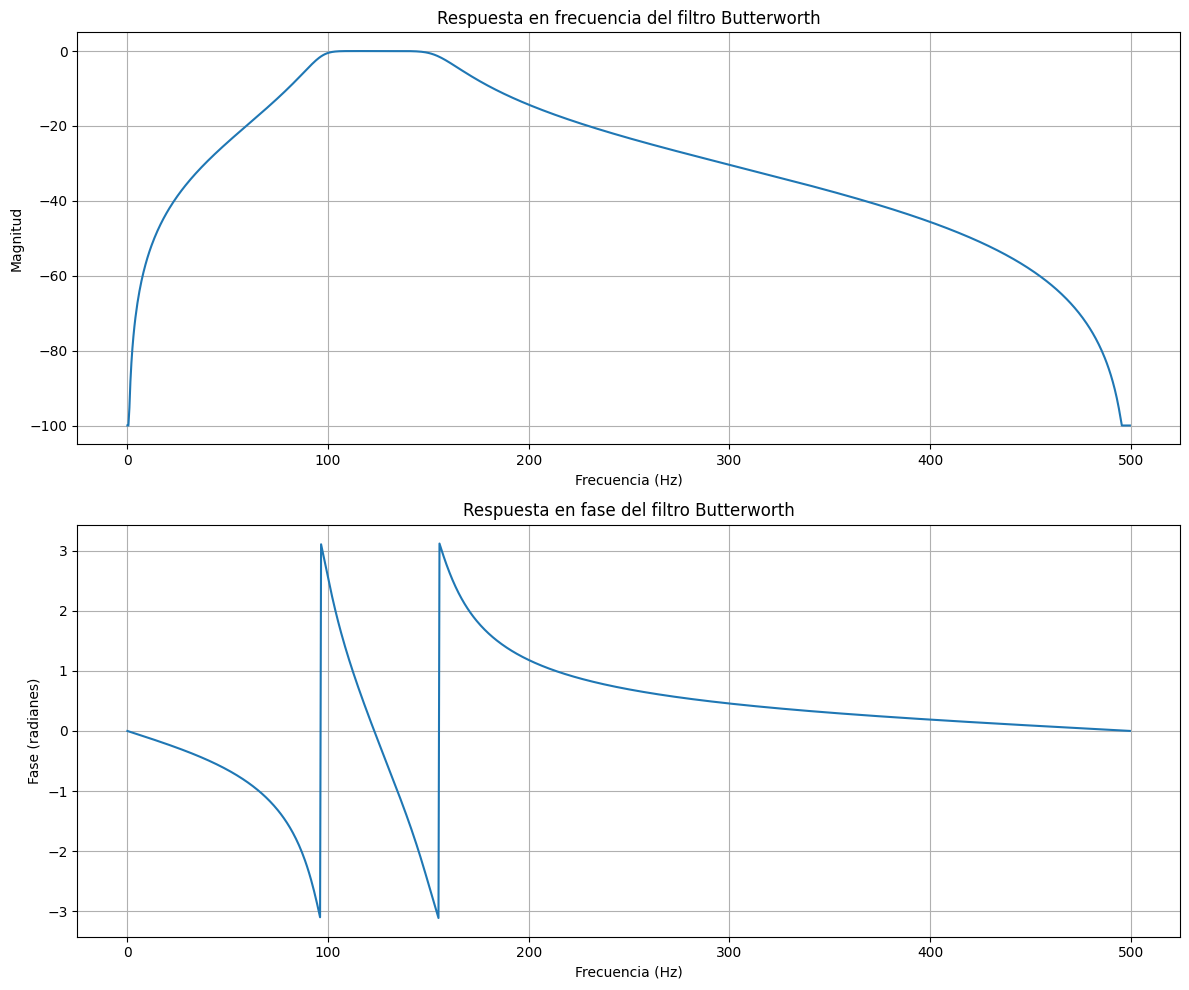

In [35]:
freqz = sig.freqz_sos(sos,worN=N, fs=fs)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(freqz[0], 10 * np.log10(np.maximum(np.abs(freqz[1]), 1e-10)))
plt.title('Respuesta en frecuencia del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqz[0], np.angle(freqz[1]))
plt.title('Respuesta en fase del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase (radianes)')
plt.grid(True)
plt.tight_layout()

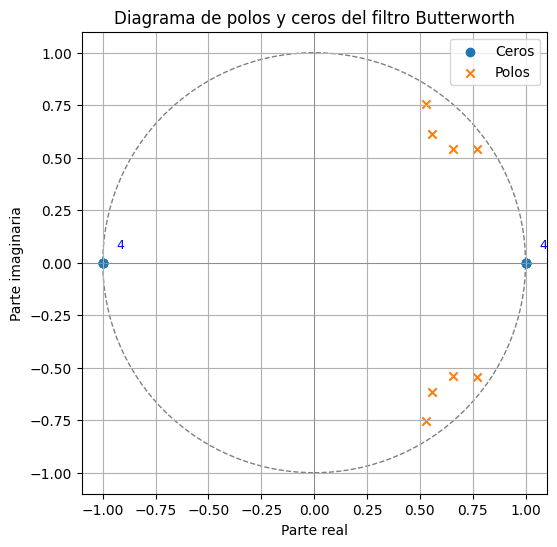

In [48]:
from collections import Counter

z, p, k = sig.sos2zpk(sos)

# Contar multiplicidad de ceros y polos
z_counter = Counter(np.round(z, decimals=10))  # Redondeamos para evitar errores de precisión
p_counter = Counter(np.round(p, decimals=10))

plt.figure(figsize=(6, 6))
plt.gca().add_patch(plt.Circle((0, 0), 1, color='gray', fill=False, ls='dashed'))
plt.scatter(np.real(z), np.imag(z), marker='o', label='Ceros')
plt.scatter(np.real(p), np.imag(p), marker='x', label='Polos')
plt.title('Diagrama de polos y ceros del filtro Butterworth')
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.legend()
plt.grid()

# Agregar multiplicidad para ceros
for zero, count in z_counter.items():
    if count > 1:
        plt.annotate(f'{count}', 
                    (np.real(zero), np.imag(zero)),
                    xytext=(10, 10), 
                    textcoords='offset points',
                    fontsize=9,
                    color='blue')

# Agregar multiplicidad para polos
for pole, count in p_counter.items():
    if count > 1:
        plt.annotate(f'{count}', 
                    (np.real(pole), np.imag(pole)),
                    xytext=(10, 10), 
                    textcoords='offset points',
                    fontsize=9,
                    color='red')

Ejemplo ECG con ruido:

Banda de paso:
FC1 = 1 Hz
FC2 = 35 Hz

FS1 = 0.1 Hz
FS2 = 50 Hz

1db de Ripple
40db de Atenuacion

Aprox orden 28


Con SOS anda, con BA no.

In [51]:
fs = 1000
N = 3000

att_min = 40

fs1 = 0.1
fc1 = 1
fc2 = 30
fs2 = 50

ripple_db = 1

fc = [fc1, fc2]
fst = [fs1, fs2]

sos_ecg = sig.iirdesign(wp=fc, ws=fst, gpass=ripple_db, gstop=att_min, 
                    ftype='butter', analog=False, 
                    fs=fs, output='sos')

b_ecg, a_ecg = sig.iirdesign(wp=fc, ws=fst, gpass=ripple_db, gstop=att_min, 
                    ftype='butter', analog=False, 
                    fs=fs, output='ba')

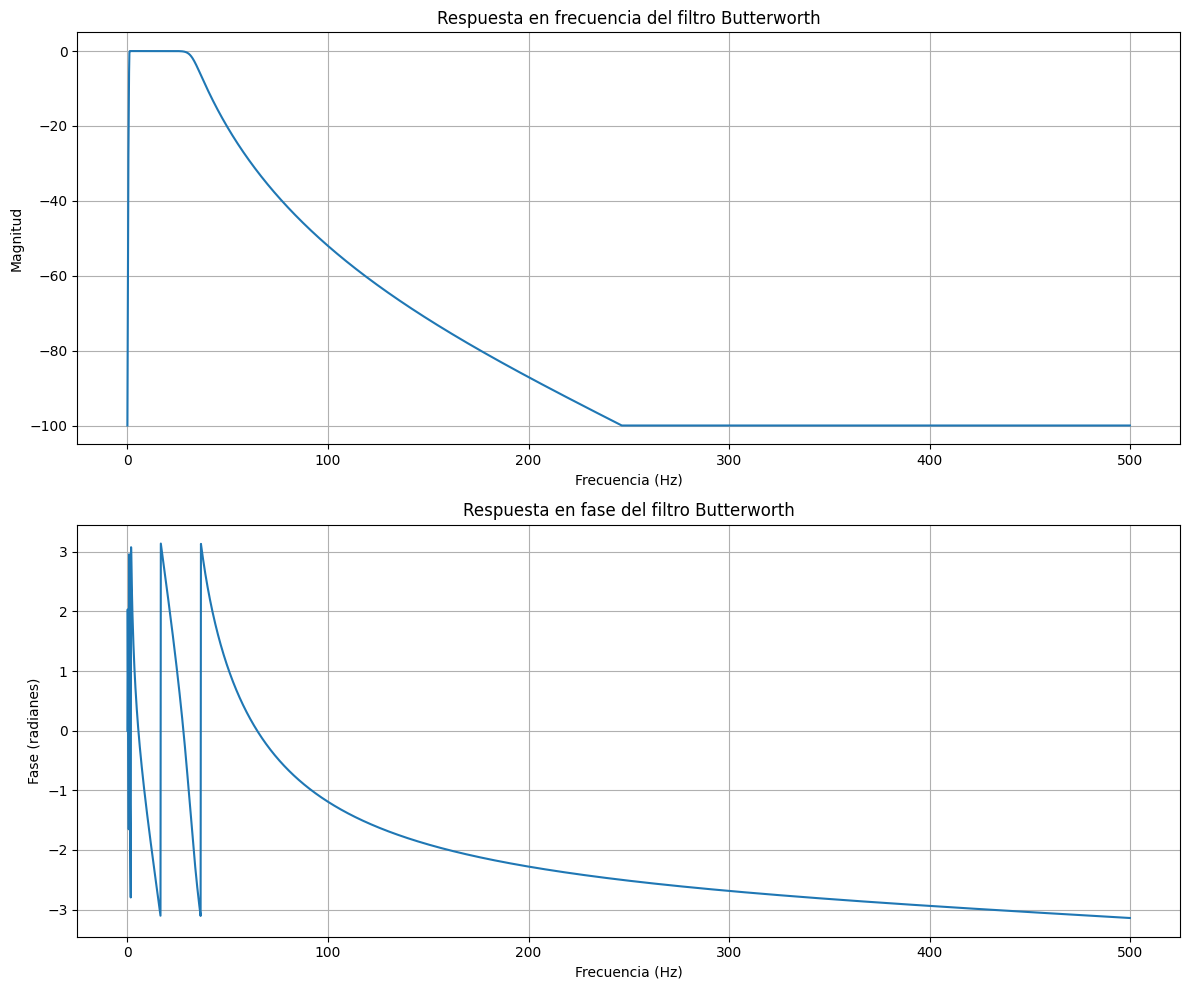

In [53]:
freqz = sig.freqz_sos(sos_ecg,worN=N, fs=fs)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(freqz[0], 10 * np.log10(np.maximum(np.abs(freqz[1]), 1e-10)))
plt.title('Respuesta en frecuencia del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqz[0], np.angle(freqz[1]))
plt.title('Respuesta en fase del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase (radianes)')
plt.grid(True)
plt.tight_layout()

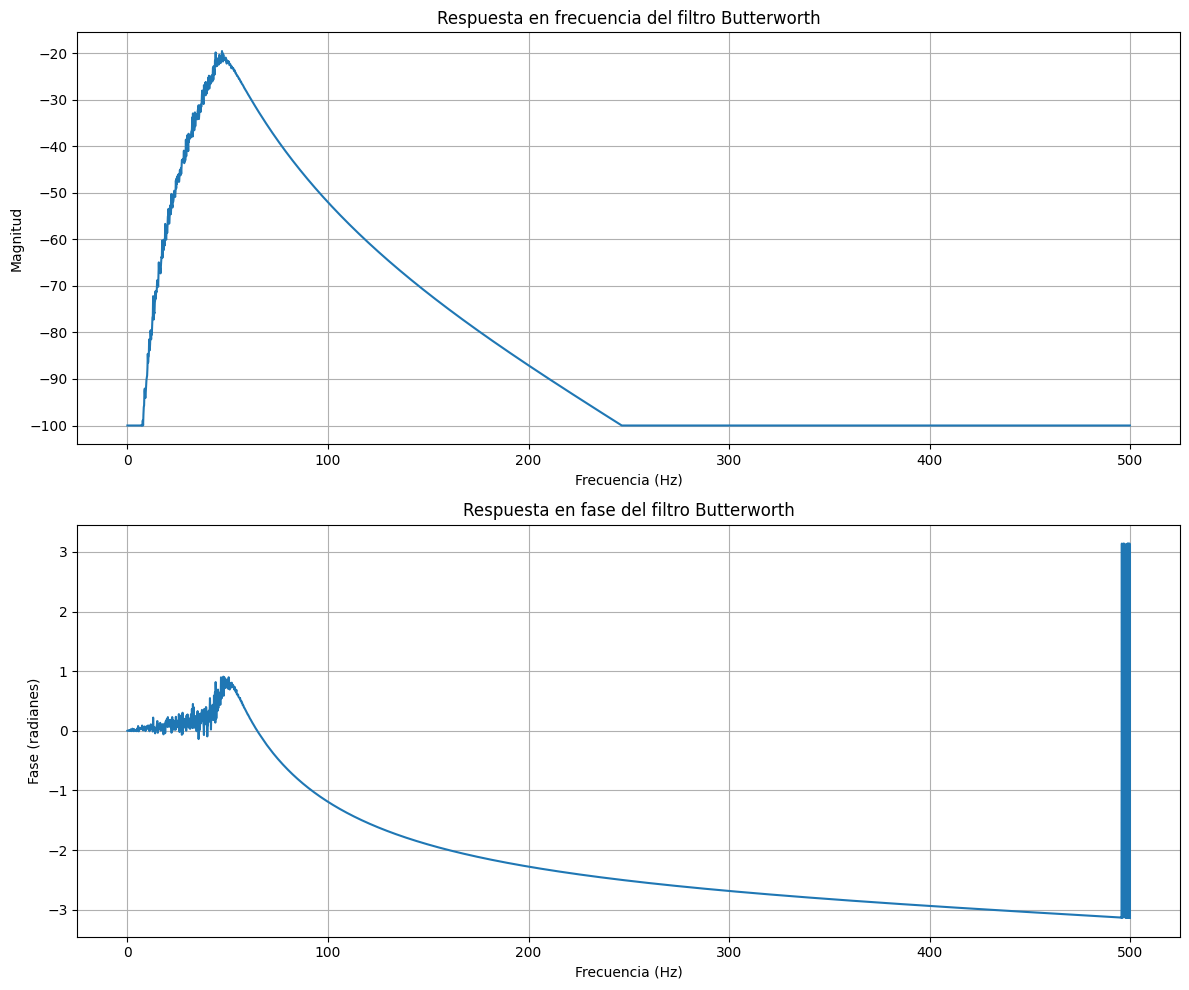

In [55]:
freqz = sig.freqz(b_ecg, a_ecg, worN=N, fs=fs)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(freqz[0], 10 * np.log10(np.maximum(np.abs(freqz[1]), 1e-10)))
plt.title('Respuesta en frecuencia del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(freqz[0], np.angle(freqz[1]))
plt.title('Respuesta en fase del filtro Butterworth')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Fase (radianes)')
plt.grid(True)
plt.tight_layout()